## Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

## Load Cleaned Dataset

In [2]:
df=pd.read_csv("../data/processed/clean_telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,1,0,1,0,No,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-12 months
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0,24-48 months
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-12 months
3,7795-CFOCW,Male,0,0,0,45,0,No,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,24-48 months
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-12 months


## Basic Dataset Overview

In [3]:
df.shape

(7043, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

In [7]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

In [9]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,0.265370
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


## Overall Churn Rate

In [10]:
churn_rate=df["Churn"].mean()*100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


## Churn Distribution Plot

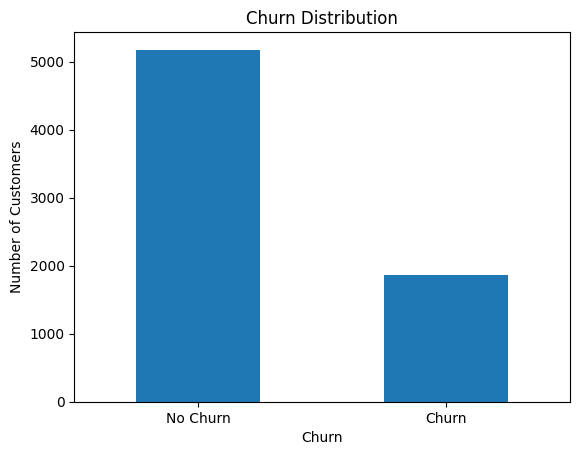

In [11]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xticks([0,1], ["No Churn", "Churn"], rotation=0)
plt.ylabel("Number of Customers")
plt.show()


## Churn by Contract Type

In [14]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn


Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Observation 
Business Insight

Usually:

Month-to-month → highest churn

Two-year contract → lowest churn


## Churn by Tenure Group

In [15]:
tenure_churn=pd.crosstab(df["TenureGroup"],df["Churn"], normalize= 'index')*100
tenure_churn

Churn,0,1
TenureGroup,,
0-12 months,52.561757,47.438243
12-24 months,71.289062,28.710938
24-48 months,79.611041,20.388959
48+ months,90.486824,9.513176


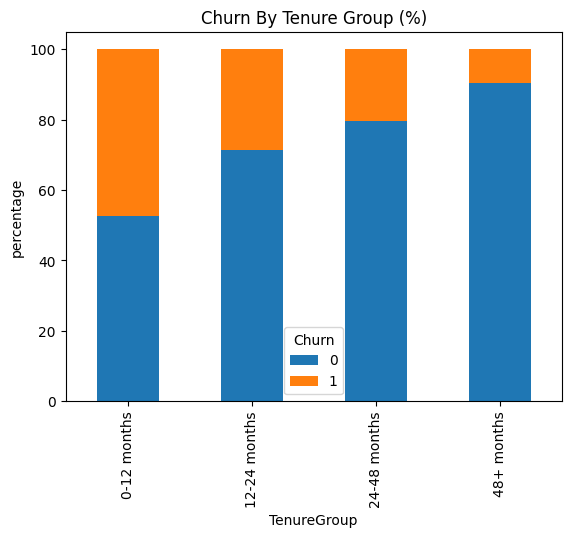

In [19]:
tenure_churn.plot(kind="bar",stacked=True)
plt.title("Churn By Tenure Group (%)")
plt.ylabel("percentage")
plt.show()

## Insight

New customers churn more.

This shows lifecycle impact.

## Monthly Charges Distribution

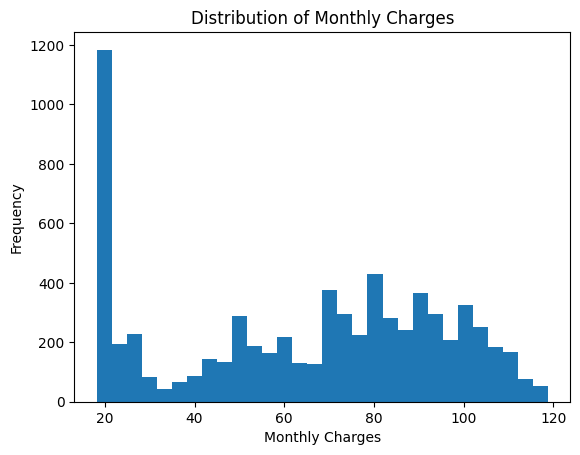

In [20]:
plt.hist(df["MonthlyCharges"], bins=30)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()


## Monthly Charges vs Churn

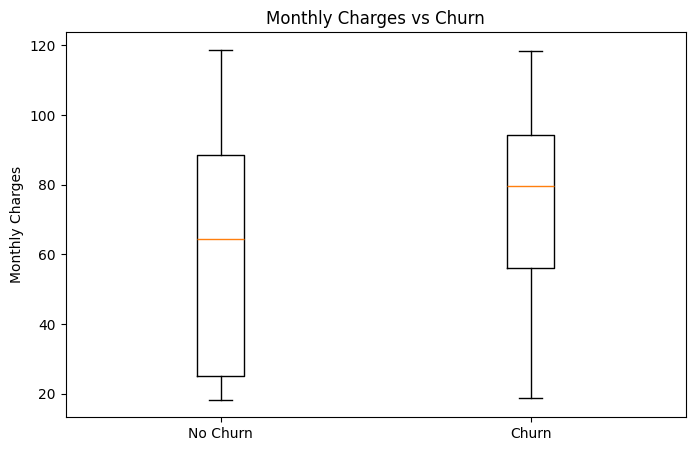

In [21]:
plt.figure(figsize=(8,5))
plt.boxplot([df[df["Churn"]==0]["MonthlyCharges"],
             df[df["Churn"]==1]["MonthlyCharges"]])
plt.xticks([1,2], ["No Churn", "Churn"])
plt.title("Monthly Charges vs Churn")
plt.ylabel("Monthly Charges")
plt.show()

## Correlation Analysis (Numeric Only)

In [22]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

correlation["Churn"].sort_values(ascending=False)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
Partner            -0.150448
Dependents         -0.164221
TotalCharges       -0.199484
tenure             -0.352229
Name: Churn, dtype: float64

## Key Insights Summary

Key Findings:

Overall churn rate is X%

Month-to-month customers show significantly higher churn.

Customers with tenure below 12 months are at highest risk.

Higher monthly charges are associated with churn.

Long-term contract customers are more stable.